# $(SA) Baseline$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Base_Line_Simple_Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='../training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
2109,66,81,"(0.1825292152212203, 0.91730535067745)","(0.361, 1.064, 0.171, -0.021)",0,1.0,"(0.382, 0.873, 0.17, 0.177)",0.0,1.0,"(0.4, 0.682, 0.174, 0.375)"
541,93,19,"(0.0642916329828742, 1.239005358213764)","(0.882, 2.81, -0.013, -0.925)",0,1.0,"(0.938, 2.623, -0.032, -0.811)",1.0,1.0,"(0.99, 2.81, -0.048, -0.93)"
1261,4,52,"(0.1449533542270192, 0.4437108072403257)","(0.012, 0.402, -0.002, -0.726)",1,1.0,"(0.02, 0.599, -0.016, -1.067)",1.0,1.0,"(0.032, 0.797, -0.038, -1.414)"
1652,40,66,"(0.0609425168772551, 1.2010637267216533)","(-0.004, 1.132, 0.051, -0.466)",1,1.0,"(0.018, 1.319, 0.041, -0.578)",1.0,1.0,"(0.045, 1.506, 0.03, -0.691)"
2117,0,82,"(0.0937864142007803, 0.3292040486028946)","(0.05, 0.035, -0.028, 0.048)",1,1.0,"(0.05, 0.238, -0.027, -0.408)",0.0,1.0,"(0.055, 0.037, -0.035, 0.022)"
...,...,...,...,...,...,...,...,...,...,...
2389,12,94,"(0.4377652476268179, 0.9729568415243506)","(-0.042, -0.357, 0.043, 0.434)",0,1.0,"(-0.049, -0.548, 0.052, 0.643)",1.0,1.0,"(-0.06, -0.357, 0.065, 0.455)"
302,4,11,"(0.7542102482276688, 0.9476222740008828)","(-0.037, -0.001, 0.007, -0.032)",0,1.0,"(-0.037, -0.196, 0.006, 0.266)",1.0,1.0,"(-0.041, -0.001, 0.011, -0.028)"
1899,3,76,"(0.0250474928798763, 0.8242933987226606)","(0.045, 0.238, 0.01, -0.137)",0,1.0,"(0.05, 0.048, 0.007, 0.033)",1.0,1.0,"(0.051, 0.237, 0.008, -0.134)"
1632,20,66,"(0.0609425168772551, 1.2010637267216533)","(-0.159, -0.356, 0.087, 0.277)",1,1.0,"(-0.166, -0.17, 0.092, 0.17)",1.0,1.0,"(-0.17, 0.017, 0.096, 0.064)"


In [3]:
model = Base_Line_Simple_Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_s,transition,reward
0,0,"[0.15488556027412415, 0.25438860058784485, 0.2...",1.973003,1.254781
1,1,"[0.15125900506973267, 0.251806378364563, 0.293...",1.952675,1.249403
2,2,"[0.1477130949497223, 0.24924439191818237, 0.28...",1.932594,1.244191
3,3,"[0.1442405879497528, 0.246702641248703, 0.2820...",1.912759,1.239083
4,4,"[0.14084026217460632, 0.2441806197166443, 0.27...",1.893167,1.234068


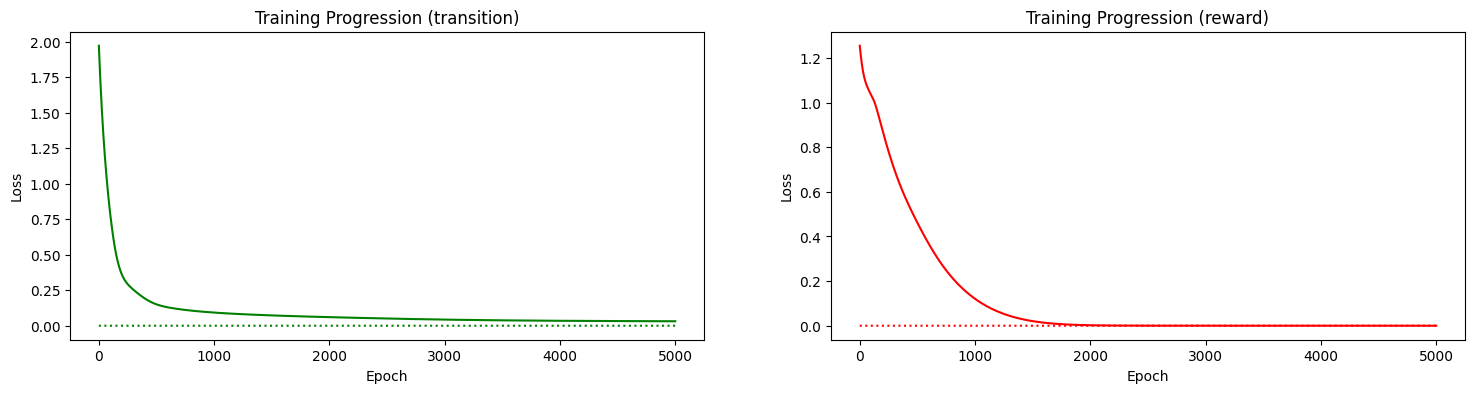

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

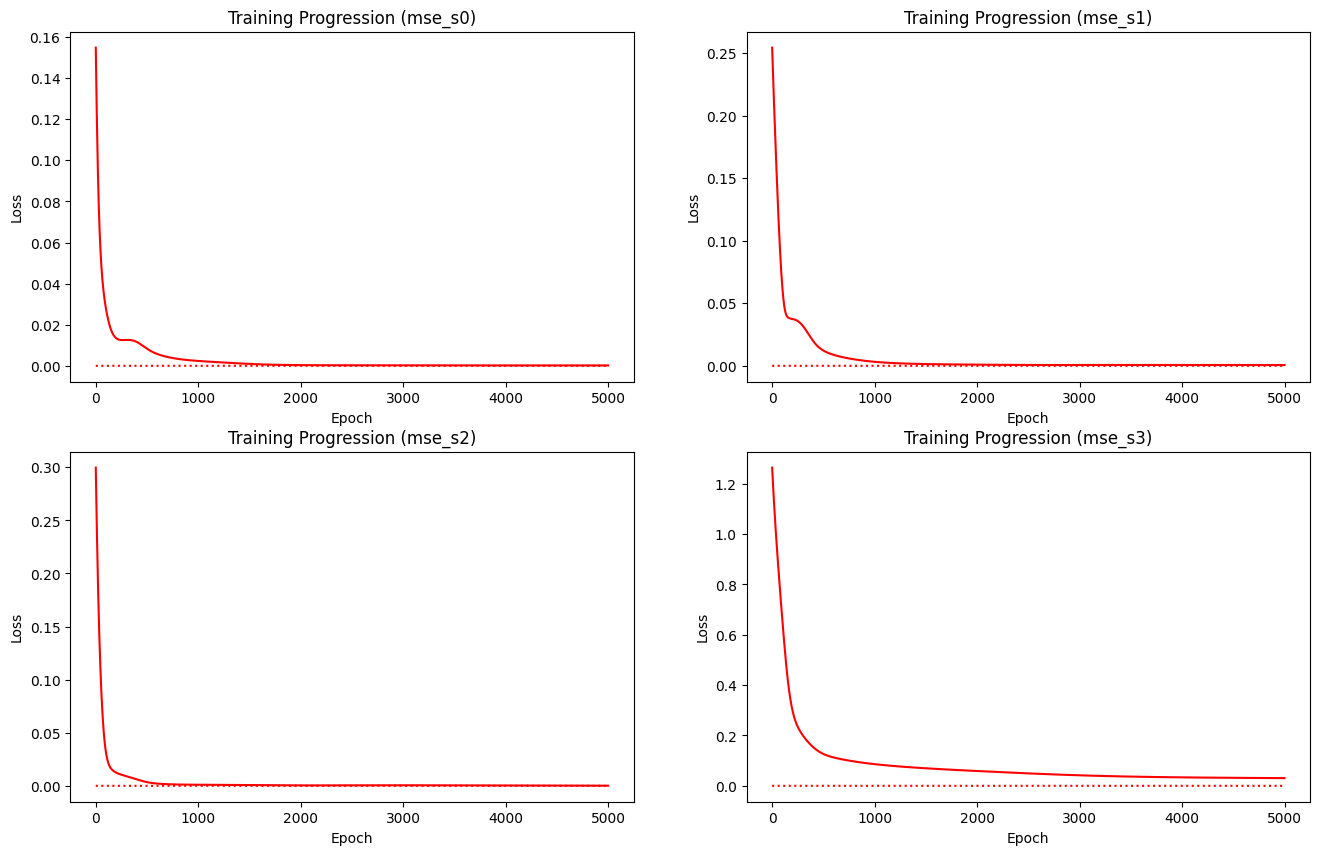

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

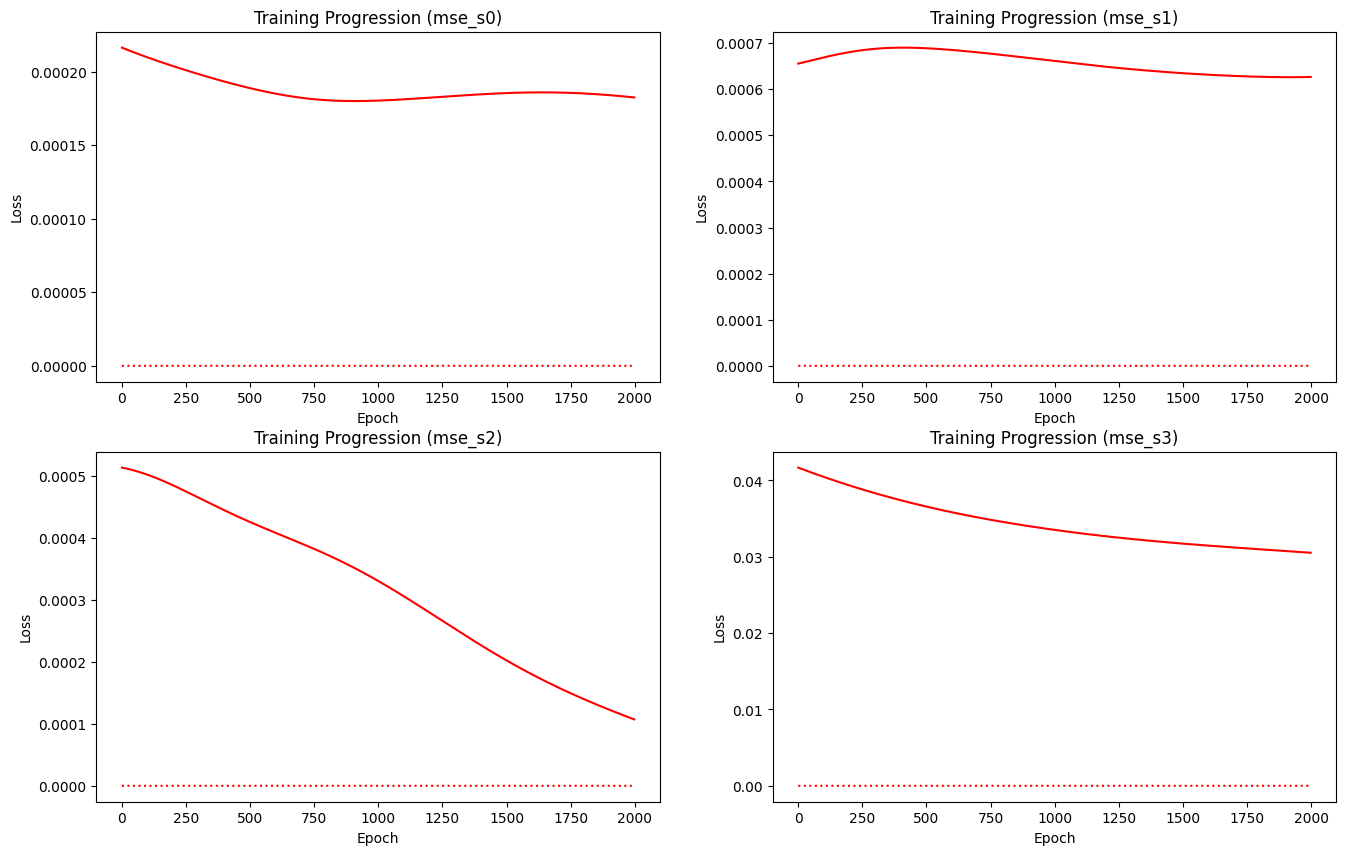

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data[train_data.epoch>3000].reset_index(drop=True), expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

# Evaluation

In [7]:
data.evaluate_model(model, path='../testing_data.csv')
results = data.get_evaluation_metrics(p=False)
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse,rse_normalized
0,0,0,"(0.5280280669895349, 0.1691488904272192)","(-0.018, -0.046, 0.013, -0.019)",0,1.0,"(-0.019, -0.285, 0.013, 1.258)",0.0,1.0,"(-0.025, -0.525, 0.038, 2.534)",...,0.066,0.024,0.688,0.0,0.567054,0.542281,0.558753,0.493540,0.798,0.540407
1,1,0,"(0.5280280669895349, 0.1691488904272192)","(-0.019, -0.285, 0.013, 1.258)",0,1.0,"(-0.025, -0.525, 0.038, 2.534)",1.0,1.0,"(-0.035, -0.288, 0.088, 1.326)",...,0.057,0.015,0.197,0.0,0.549102,0.540069,0.537170,0.451527,0.272,0.519467
2,2,0,"(0.5280280669895349, 0.1691488904272192)","(-0.025, -0.525, 0.038, 2.534)",1,1.0,"(-0.035, -0.288, 0.088, 1.326)",0.0,1.0,"(-0.041, -0.532, 0.115, 2.694)",...,0.047,0.020,0.853,0.0,0.549102,0.537611,0.549161,0.507658,0.923,0.535883
3,3,0,"(0.5280280669895349, 0.1691488904272192)","(-0.035, -0.288, 0.088, 1.326)",0,1.0,"(-0.041, -0.532, 0.115, 2.694)",1.0,1.0,"(-0.052, -0.3, 0.169, 1.601)",...,0.091,0.008,0.188,0.0,0.549102,0.548427,0.520384,0.450757,0.290,0.517168
4,4,0,"(0.5280280669895349, 0.1691488904272192)","(-0.041, -0.532, 0.115, 2.694)",1,1.0,"(-0.052, -0.3, 0.169, 1.601)",0.0,1.0,"(-0.058, -0.546, 0.201, 3.045)",...,0.016,0.014,0.901,0.0,0.559662,0.529990,0.534772,0.511765,0.944,0.534047


In [8]:
results[['rse', 'rse_normalized', 
         'rse_s0', 'rse_s0_normalized',
         'rse_s1', 'rse_s1_normalized', 
         'rse_s2', 'rse_s2_normalized',
         'rse_s3', 'rse_s3_normalized']].describe()

,rse,rse_normalized,rse_s0,rse_s0_normalized,rse_s1,rse_s1_normalized,rse_s2,rse_s2_normalized,rse_s3,rse_s3_normalized
count,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000
mean,0.155054,0.511604,0.007343,0.553689,0.015627,0.529899,0.006771,0.517435,0.125313,0.445393
std,0.168967,0.008219,0.007770,0.008205,0.019480,0.004788,0.008731,0.020938,0.158504,0.013562
min,0.006000,0.502583,0.000000,0.545935,0.000000,0.526057,0.000000,0.501199,0.000000,0.434671
25%,0.063000,0.506772,0.002000,0.548046,0.003000,0.526794,0.002000,0.505995,0.038000,0.437922
50%,0.107000,0.508987,0.005000,0.551214,0.009000,0.528269,0.004000,0.510791,0.079000,0.441431
75%,0.186000,0.513610,0.010000,0.556494,0.021000,0.531219,0.007500,0.519185,0.151000,0.447591
max,2.058000,0.594314,0.107000,0.658923,0.145000,0.561701,0.118000,0.784173,1.951000,0.601609


In [9]:
import numpy as np 
n = 10

worst = results.loc[results.rank(ascending=False)['rse']<=n].episode
df = results[results['episode'].isin(worst)].reset_index(drop=True)

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/pyt

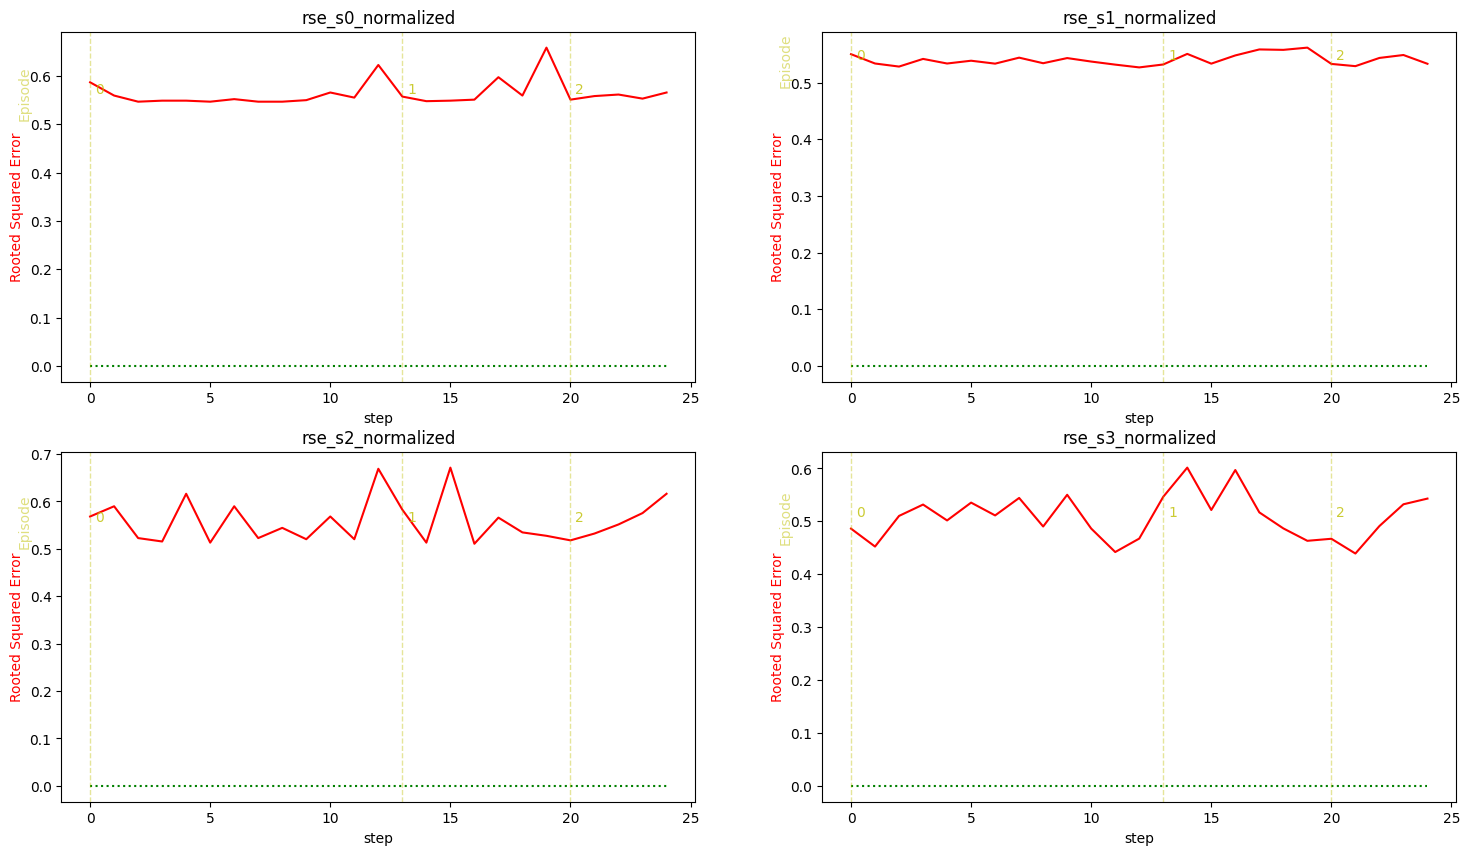

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], df, 'rse_s0_normalized')
data.plot_value_through_episodes(axs[0][1], df, 'rse_s1_normalized')
data.plot_value_through_episodes(axs[1][0], df, 'rse_s2_normalized')
data.plot_value_through_episodes(axs[1][1], df, 'rse_s3_normalized')

plt.show()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


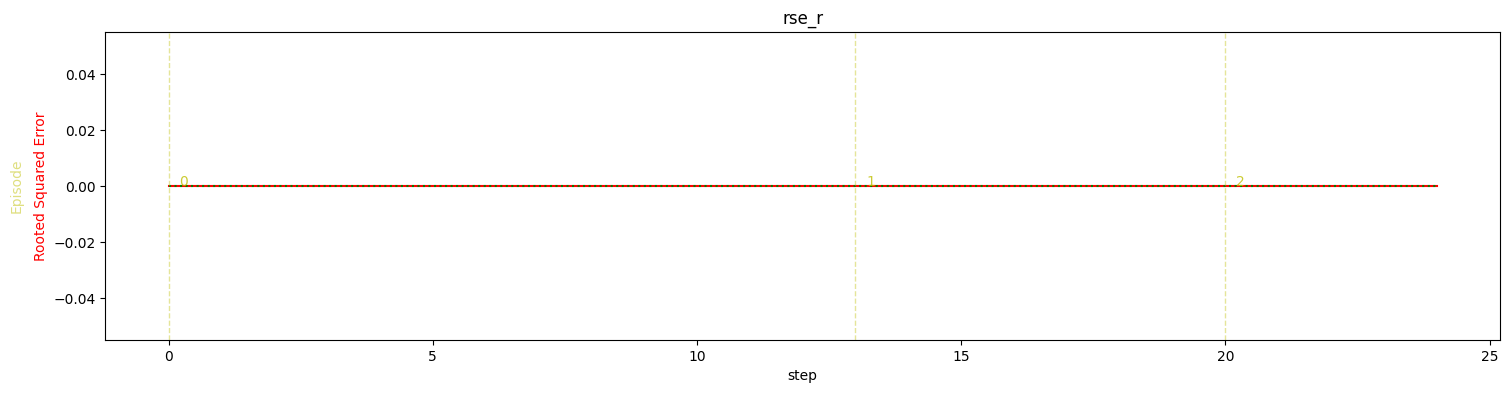

In [11]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, df, 'rse_r')
plt.show()

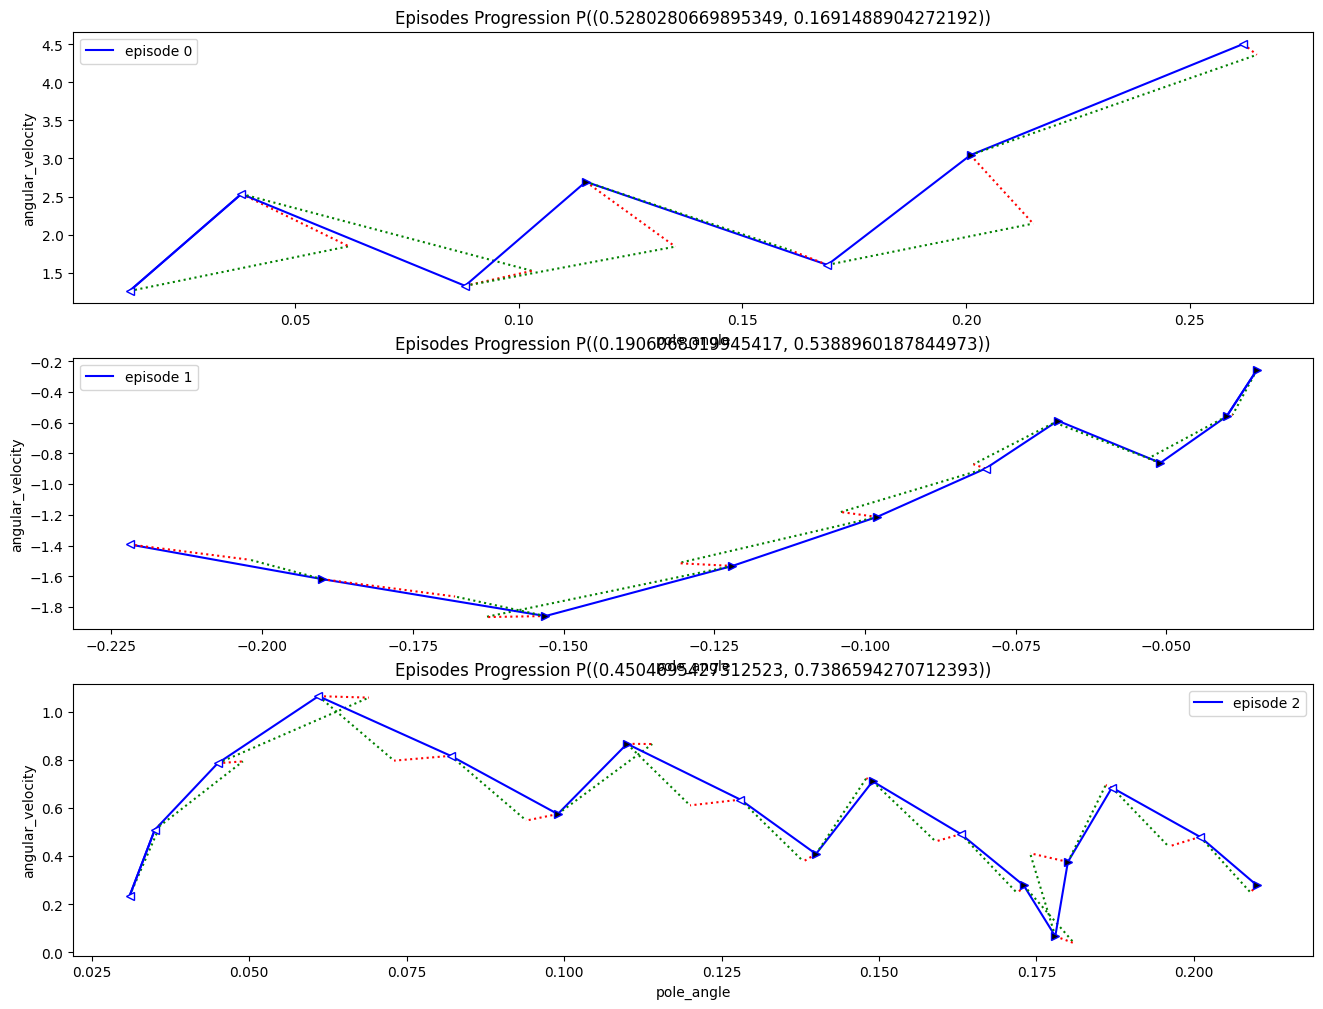

In [12]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()